# Processed Data Validation
This notebook validates the outputs of `data/preprocess.py` to confirm that preprocessing was applied correctly.

We check:
1. Train/Val/Test split sizes (~70/15/15)
2. Class balance across splits
3. Scaling behavior (means near 0, SDs near 1)
4. Engineered columns exist (BMI_Category, BP_Range, Glucose_Insulin_Ratio)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Processed Data

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_val = pd.read_csv('../data/X_val.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_val = pd.read_csv('../data/y_val.csv')
y_test = pd.read_csv('../data/y_test.csv')

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (536, 11)
X_val shape:   (116, 11)
X_test shape:  (116, 11)


## 2. Validate Split Sizes (~70/15/15)

Total records: 768
Train: 536 (69.8%)
Val:   116 (15.1%)
Test:  116 (15.1%)



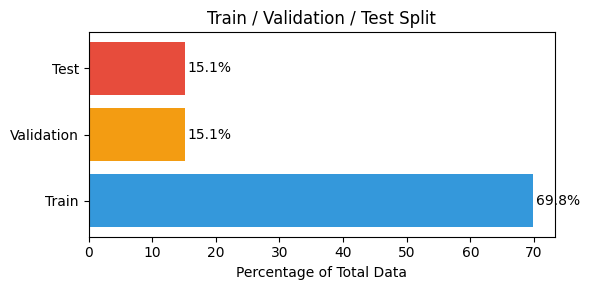

Split sizes are within expected range.


In [3]:
total = len(X_train) + len(X_val) + len(X_test)
train_pct = len(X_train) / total * 100
val_pct = len(X_val) / total * 100
test_pct = len(X_test) / total * 100

print(f'Total records: {total}')
print(f'Train: {len(X_train)} ({train_pct:.1f}%)')
print(f'Val:   {len(X_val)} ({val_pct:.1f}%)')
print(f'Test:  {len(X_test)} ({test_pct:.1f}%)')
print()

# Visual
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(['Train', 'Validation', 'Test'], [train_pct, val_pct, test_pct], color=['#3498db', '#f39c12', '#e74c3c'])
ax.set_xlabel('Percentage of Total Data')
ax.set_title('Train / Validation / Test Split')
for i, v in enumerate([train_pct, val_pct, test_pct]):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

assert 65 < train_pct < 75, f'Train split unexpected: {train_pct:.1f}%'
assert 12 < val_pct < 18, f'Val split unexpected: {val_pct:.1f}%'
assert 12 < test_pct < 18, f'Test split unexpected: {test_pct:.1f}%'
print('Split sizes are within expected range.')

## 3. Class Balance Across Splits
We used stratified splitting, so the ratio of diabetic to non-diabetic should be similar across all three sets.

Train: 349 non-diabetic, 187 diabetic (34.9% diabetic)
Validation: 75 non-diabetic, 41 diabetic (35.3% diabetic)
Test: 76 non-diabetic, 40 diabetic (34.5% diabetic)



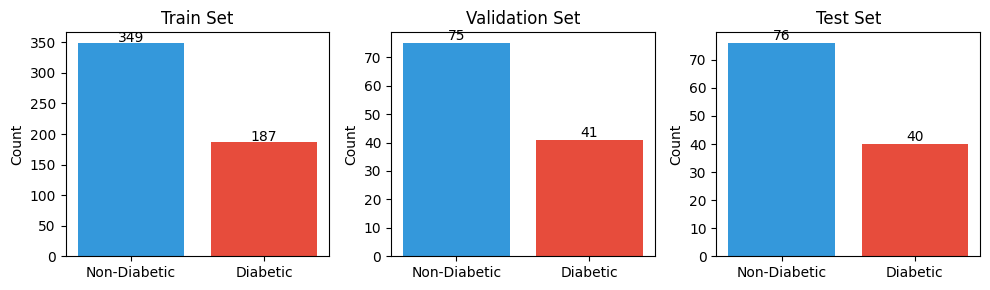

Class balance is consistent across splits (stratified split confirmed).


In [4]:
for name, y in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    counts = y['Outcome'].value_counts()
    pct_diabetic = counts[1] / len(y) * 100
    print(f'{name}: {counts[0]} non-diabetic, {counts[1]} diabetic ({pct_diabetic:.1f}% diabetic)')

print()

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (name, y) in zip(axes, [('Train', y_train), ('Validation', y_val), ('Test', y_test)]):
    counts = y['Outcome'].value_counts()
    ax.bar(['Non-Diabetic', 'Diabetic'], [counts[0], counts[1]], color=['#3498db', '#e74c3c'])
    ax.set_title(f'{name} Set')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

print('Class balance is consistent across splits (stratified split confirmed).')

## 4. Validate Scaling (Means ≈ 0, SDs ≈ 1)
StandardScaler was fit on the training set. We expect training means near 0 and standard deviations near 1. Validation and test sets may deviate slightly since the scaler was fit only on training data (no data leakage).

In [5]:
train_means = X_train.mean()
train_stds = X_train.std()

scaling_check = pd.DataFrame({
    'Feature': X_train.columns,
    'Train Mean': train_means.values,
    'Train Std': train_stds.values
})
print(scaling_check.to_string(index=False))
print()

# Check that means are close to 0 and stds close to 1
mean_ok = all(abs(m) < 0.1 for m in train_means)
std_ok = all(abs(s - 1.0) < 0.15 for s in train_stds)

if mean_ok and std_ok:
    print('Scaling validated: all training means near 0 and SDs near 1.')
else:
    print('WARNING: Some features may not be properly scaled.')
    if not mean_ok:
        print(f'  Means not near 0: {[f for f, m in zip(X_train.columns, train_means) if abs(m) >= 0.1]}')
    if not std_ok:
        print(f'  SDs not near 1: {[f for f, s in zip(X_train.columns, train_stds) if abs(s - 1.0) >= 0.15]}')

                 Feature    Train Mean  Train Std
             Pregnancies -4.639738e-17   1.000934
                 Glucose -1.234502e-16   1.000934
           BloodPressure -2.154164e-16   1.000934
           SkinThickness  9.610886e-17   1.000934
                 Insulin  3.976918e-17   1.000934
                     BMI -3.645508e-16   1.000934
DiabetesPedigreeFunction -3.479804e-17   1.000934
                     Age  5.633968e-17   1.000934
            BMI_Category -1.889036e-16   1.000934
                BP_Range  5.965377e-17   1.000934
   Glucose_Insulin_Ratio -4.142623e-16   1.000934

Scaling validated: all training means near 0 and SDs near 1.


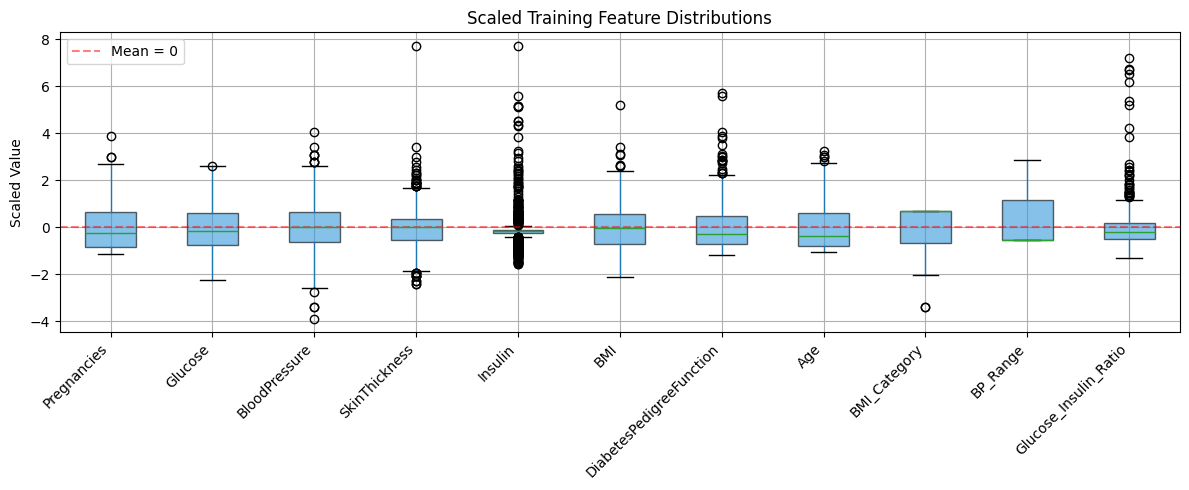

In [6]:
# Visualize: boxplots of scaled training features
fig, ax = plt.subplots(figsize=(12, 5))
X_train.boxplot(ax=ax, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6))
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Mean = 0')
ax.set_title('Scaled Training Feature Distributions')
ax.set_ylabel('Scaled Value')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Confirm Engineered Columns Exist

In [7]:
expected_engineered = ['BMI_Category', 'BP_Range', 'Glucose_Insulin_Ratio']

print(f'All columns in training set: {list(X_train.columns)}')
print()

for col in expected_engineered:
    if col in X_train.columns:
        print(f'  {col}: PRESENT (unique values: {sorted(X_train[col].unique())[:10]})')
    else:
        print(f'  {col}: MISSING')

all_present = all(col in X_train.columns for col in expected_engineered)
print()
if all_present:
    print('All engineered features confirmed present in the dataset.')
else:
    missing = [col for col in expected_engineered if col not in X_train.columns]
    print(f'WARNING: Missing engineered features: {missing}')

All columns in training set: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Category', 'BP_Range', 'Glucose_Insulin_Ratio']

  BMI_Category: PRESENT (unique values: [np.float64(-3.398035627613507), np.float64(-2.0286017205452067), np.float64(-0.659167813476906), np.float64(0.7102660935913945)])
  BP_Range: PRESENT (unique values: [np.float64(-0.5517945738221658), np.float64(1.147986412204736), np.float64(2.8477673982316376)])
  Glucose_Insulin_Ratio: PRESENT (unique values: [np.float64(-1.3012542495872264), np.float64(-1.26959136495436), np.float64(-1.2653209505342085), np.float64(-1.2511412386388197), np.float64(-1.2489708970219398), np.float64(-1.2230128528313395), np.float64(-1.1534925351696723), np.float64(-1.152195770209254), np.float64(-1.143769621112311), np.float64(-1.1422292733351551)])

All engineered features confirmed present in the dataset.


## 6. Summary

**Validation Results:**
- Split sizes match the expected 70/15/15 ratio
- Class balance is consistent across train, validation, and test sets (stratified split)
- StandardScaler was applied correctly — training means are near 0, standard deviations near 1
- All three engineered features (BMI_Category, BP_Range, Glucose_Insulin_Ratio) are present

The preprocessing pipeline output is validated and ready for model training.